# Лабораторная работа №3. Изображения и видео

В этой работе нужно извлечь разметку объектов из видео с уже нарисованными рамками\
После этого сравним найденные рамки с исходной разметкой, сохраним результат в COCO и обучим модель детекции

## 1. Декодирование видео в последовательность кадров

На этом шаге проверим, что оба видео читаются корректно\
Также сравним размер, FPS и количество кадров, чтобы дальше можно было обрабатывать кадры попарно

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
DATA_DIR = Path("data")

INPUT_VIDEO_PATH = DATA_DIR / "input.mp4"
OUTPUT_VIDEO_PATH = DATA_DIR / "output.mp4"
ANNOTATIONS_PATH = DATA_DIR / "annotations.xml"

print("Путь к исходному видео:", INPUT_VIDEO_PATH)
print("Путь к видео с разметкой:", OUTPUT_VIDEO_PATH)
print("Путь к XML-разметке:", ANNOTATIONS_PATH)

Путь к исходному видео: data/input.mp4
Путь к видео с разметкой: data/output.mp4
Путь к XML-разметке: data/annotations.xml


In [5]:
def get_video_info(video_path):
    """Возвращает основные параметры видеофайла"""
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        raise ValueError(f"Не удалось открыть видео: {video_path}")
    
    info = {
        "путь": str(video_path),
        "ширина": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "высота": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "число_кадров": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    }
    
    cap.release()
    return info


input_info = get_video_info(INPUT_VIDEO_PATH)
output_info = get_video_info(OUTPUT_VIDEO_PATH)

video_info_df = pd.DataFrame([input_info, output_info])
video_info_df

,путь,ширина,высота,fps,число_кадров
0,data/input.mp4,1920,1080,30.0,301
1,data/output.mp4,1920,1080,30.0,301


In [6]:
assert input_info["ширина"] == output_info["ширина"], "Ширина видео не совпадает"
assert input_info["высота"] == output_info["высота"], "Высота видео не совпадает"
assert input_info["число_кадров"] == output_info["число_кадров"], "Количество кадров не совпадает"

print("Видео совпадают по размеру и количеству кадров")
print(f"Размер кадра: {input_info['ширина']}x{input_info['высота']}")
print(f"Количество кадров: {input_info['число_кадров']}")
print(f"FPS: {input_info['fps']}")

Видео совпадают по размеру и количеству кадров
Размер кадра: 1920x1080
Количество кадров: 301
FPS: 30.0


In [7]:
def read_frame(video_path, frame_index):
    """Читает один кадр по его номеру"""
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    
    success, frame = cap.read()
    cap.release()
    
    if not success:
        raise ValueError(f"Не удалось прочитать кадр {frame_index} из видео {video_path}")
    
    return frame


frame_index = 100

input_frame = read_frame(INPUT_VIDEO_PATH, frame_index)
output_frame = read_frame(OUTPUT_VIDEO_PATH, frame_index)

print("Форма кадра из исходного видео:", input_frame.shape)
print("Форма кадра из видео с разметкой:", output_frame.shape)

Форма кадра из исходного видео: (1080, 1920, 3)
Форма кадра из видео с разметкой: (1080, 1920, 3)


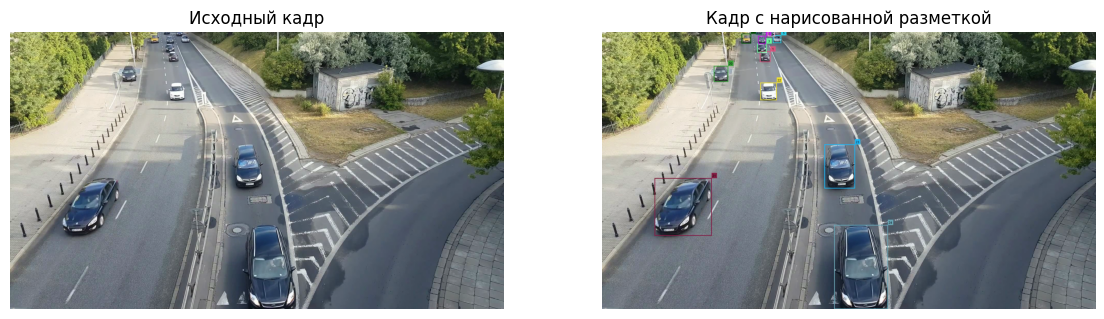

In [8]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(input_frame, cv2.COLOR_BGR2RGB))
plt.title("Исходный кадр")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB))
plt.title("Кадр с нарисованной разметкой")
plt.axis("off")

plt.show()

### Сохранение кадров на диск

Сохраним кадры из обоих видео в отдельные папки\
Это удобно для проверки, построения COCO датасета и дальнейшего обучения модели

In [10]:
FRAMES_DIR = DATA_DIR / "frames"
INPUT_FRAMES_DIR = FRAMES_DIR / "input"
OUTPUT_FRAMES_DIR = FRAMES_DIR / "output"

INPUT_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Папка для кадров исходного видео:", INPUT_FRAMES_DIR)
print("Папка для кадров видео с разметкой:", OUTPUT_FRAMES_DIR)

Папка для кадров исходного видео: data/frames/input
Папка для кадров видео с разметкой: data/frames/output


In [11]:
def save_video_frames(video_path, output_dir):
    """Сохраняет все кадры видео в отдельную папку"""
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        raise ValueError(f"Не удалось открыть видео: {video_path}")
    
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    saved_count = 0
    
    for frame_index in range(frame_count):
        success, frame = cap.read()
        
        if not success:
            print(f"Не удалось прочитать кадр {frame_index}")
            break
        
        frame_path = output_dir / f"frame_{frame_index:06d}.jpg"
        cv2.imwrite(str(frame_path), frame)
        saved_count += 1
    
    cap.release()
    
    print(f"Видео {video_path.name}: сохранено кадров {saved_count} из {frame_count}")
    return saved_count

In [12]:
saved_input_count = save_video_frames(INPUT_VIDEO_PATH, INPUT_FRAMES_DIR)
saved_output_count = save_video_frames(OUTPUT_VIDEO_PATH, OUTPUT_FRAMES_DIR)

print("Кадров из исходного видео:", saved_input_count)
print("Кадров из видео с разметкой:", saved_output_count)

Видео input.mp4: сохранено кадров 301 из 301
Видео output.mp4: сохранено кадров 301 из 301
Кадров из исходного видео: 301
Кадров из видео с разметкой: 301


In [13]:
assert saved_input_count == saved_output_count, "Количество сохраненных кадров не совпадает"

print("Кадры успешно сохранены")

Кадры успешно сохранены
